# 1.Feature Engineering

This notebook contain Feature Engineering in 3 aspects for our arrest prediction:

- Temporal feature
- Spatial(location type) feature
- Crime Type Mapping for Chicago dataset 

## Load Dataset

In [27]:
import os
import pandas as pd
import numpy as np

nb_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(nb_dir, ".."))
folder_path = os.path.join(project_root, "data")

file_list = [
    os.path.join(folder_path, f"train_{year}.csv")
    for year in range(2015, 2025)
]

missing_files = [f for f in file_list if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f"Missing files: {missing_files}")

df_chicago = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in file_list],
    ignore_index=True
)

print("Chicago dataset shape:", df_chicago.shape)
print(df_chicago.head())

Chicago dataset shape: (2519517, 22)
         ID Case Number                    Date                     Block  \
0  10365064    HZ100370  12/31/2015 11:59:00 PM       075XX S EMERALD AVE   
1  10460641    HZ199559  12/31/2015 11:59:00 PM        015XX N KEDZIE AVE   
2  10364662    HZ100006  12/31/2015 11:55:00 PM  079XX S STONY ISLAND AVE   
3  10364740    HZ100010  12/31/2015 11:50:00 PM         024XX W FARGO AVE   
4  10364683    HZ100002  12/31/2015 11:50:00 PM          037XX N CLARK ST   

   IUCR     Primary Type                    Description  \
0  1320  CRIMINAL DAMAGE                     TO VEHICLE   
1  0890            THEFT                  FROM BUILDING   
2  0430          BATTERY  AGGRAVATED: OTHER DANG WEAPON   
3  0820            THEFT                 $500 AND UNDER   
4  0460          BATTERY                         SIMPLE   

      Location Description  Arrest  Domestic  ...  Ward  Community Area  \
0                   STREET   False     False  ...  17.0            68.

## Spatial Feature Engineering

### Mapping Standard for Location Type

This document provides a mapping standard for the location type feature in datasets. The goal is to create a common set of categories that can be used across different datasets to ensure consistency and comparability.

| Common Category         | Chicago Dataset (Location Description) | 
|-------------------------|--------------------------------|
| **Residence**          | RESIDENCE, HOUSE, APARTMENT, RESIDENCE - YARD (FRONT / BACK), RESIDENCE - GARAGE, RESIDENCE - PORCH / HALLWAY, DRIVEWAY - RESIDENTIAL | 
| **Street/Outdoor**     | ALLEY, STREET, SIDEWALK, VACANT LOT / LAND, PARK PROPERTY, BRIDGE, HIGHWAY / EXPRESSWAY, LAKEFRONT / WATERFRONT / RIVERBANK |
| **Transportation Hub**  | CTA PLATFORM, CTA BUS, CTA TRAIN, CTA STATION, AIRPORT TERMINAL LOWER LEVEL - SECURE AREA, AIRPORT PARKING LOT, AIRPORT TERMINAL UPPER LEVEL - SECURE AREA |
| **Retail/Commercial**  | SMALL RETAIL STORE, GROCERY FOOD STORE, DEPARTMENT STORE, DRUG STORE, CONVENIENCE STORE, CURRENCY EXCHANGE, BANK, PAWN SHOP, LIQUOR STORE |
| **Entertainment**      | BAR OR TAVERN, TAVERN / LIQUOR STORE, MOVIE HOUSE / THEATER, SPORTS ARENA / STADIUM, BOWLING ALLEY |
| **Government/Public**  | GOVERNMENT BUILDING / PROPERTY, POLICE FACILITY, FIRE STATION, SCHOOL - PUBLIC BUILDING, LIBRARY | 
| **Medical Facility**   | HOSPITAL BUILDING / GROUNDS, MEDICAL / DENTAL OFFICE, NURSING / RETIREMENT HOME, ANIMAL HOSPITAL |
| **Workplace/Office**   | COMMERCIAL / BUSINESS OFFICE, FACTORY / MANUFACTURING BUILDING | 
| **Parking Lot**        | PARKING LOT / GARAGE (NON RESIDENTIAL), CHA PARKING LOT / GROUNDS | 
| **Unknown/Other**      | OTHER (SPECIFY), ATM (AUTOMATIC TELLER MACHINE), COIN OPERATED MACHINE | 

### Location mapping for Chicago Crime Dataset
The `key` i s from "Location Description" column in the dataset. The `value` is the corresponding location type. The mapping is based on the description of the location in the dataset and common sense knowledge about the types of locations.

In [28]:
# -----------------------------
# Spatial Feature Engineering
# -----------------------------
df_chicago["Location Description"] = (
    df_chicago["Location Description"]
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
    .str.upper()
)

location_mapping = {
    # Residence
    "RESIDENCE": "Residence",
    "HOUSE": "Residence",
    "APARTMENT": "Residence",
    "RESIDENCE - YARD (FRONT / BACK)": "Residence",
    "RESIDENCE - GARAGE": "Residence",
    "RESIDENCE - PORCH / HALLWAY": "Residence",
    "RESIDENCE PORCH/HALLWAY": "Residence",
    "DRIVEWAY - RESIDENTIAL": "Residence",

    # Street / Outdoor
    "STREET": "Street/Outdoor",
    "ALLEY": "Street/Outdoor",
    "SIDEWALK": "Street/Outdoor",
    "VACANT LOT / LAND": "Street/Outdoor",
    "PARK PROPERTY": "Street/Outdoor",
    "BRIDGE": "Street/Outdoor",
    "HIGHWAY / EXPRESSWAY": "Street/Outdoor",
    "LAKEFRONT / WATERFRONT / RIVERBANK": "Street/Outdoor",

    # Transportation Hub
    "CTA PLATFORM": "Transportation Hub",
    "CTA BUS": "Transportation Hub",
    "CTA TRAIN": "Transportation Hub",
    "CTA STATION": "Transportation Hub",
    "AIRPORT TERMINAL LOWER LEVEL - SECURE AREA": "Transportation Hub",
    "AIRPORT PARKING LOT": "Transportation Hub",
    "AIRPORT TERMINAL UPPER LEVEL - SECURE AREA": "Transportation Hub",

    # Retail / Commercial
    "SMALL RETAIL STORE": "Retail/Commercial",
    "GROCERY FOOD STORE": "Retail/Commercial",
    "DEPARTMENT STORE": "Retail/Commercial",
    "DRUG STORE": "Retail/Commercial",
    "CONVENIENCE STORE": "Retail/Commercial",
    "CURRENCY EXCHANGE": "Retail/Commercial",
    "BANK": "Retail/Commercial",
    "PAWN SHOP": "Retail/Commercial",
    "LIQUOR STORE": "Retail/Commercial",

    # Entertainment
    "BAR OR TAVERN": "Entertainment",
    "TAVERN / LIQUOR STORE": "Entertainment",
    "MOVIE HOUSE / THEATER": "Entertainment",
    "SPORTS ARENA / STADIUM": "Entertainment",
    "BOWLING ALLEY": "Entertainment",

    # Government / Public
    "GOVERNMENT BUILDING / PROPERTY": "Government/Public",
    "POLICE FACILITY": "Government/Public",
    "FIRE STATION": "Government/Public",
    "SCHOOL - PUBLIC BUILDING": "Government/Public",
    "LIBRARY": "Government/Public",

    # Medical Facility
    "HOSPITAL BUILDING / GROUNDS": "Medical Facility",
    "MEDICAL / DENTAL OFFICE": "Medical Facility",
    "NURSING / RETIREMENT HOME": "Medical Facility",
    "ANIMAL HOSPITAL": "Medical Facility",

    # Workplace / Office
    "COMMERCIAL / BUSINESS OFFICE": "Workplace/Office",
    "FACTORY / MANUFACTURING BUILDING": "Workplace/Office",

    # Parking
    "PARKING LOT / GARAGE (NON RESIDENTIAL)": "Parking Lot",
    "CHA PARKING LOT / GROUNDS": "Parking Lot",

    # Unknown / Other
    "OTHER (SPECIFY)": "Unknown/Other",
    "ATM (AUTOMATIC TELLER MACHINE)": "Unknown/Other",
    "COIN OPERATED MACHINE": "Unknown/Other",
    "UNKNOWN": "Unknown/Other"
}

df_chicago["unified_location_category"] = (
    df_chicago["Location Description"]
    .map(location_mapping)
    .fillna("Unknown/Other")
)

print(df_chicago[["Location Description", "unified_location_category"]].head(10))
print(df_chicago["unified_location_category"].value_counts())

      Location Description unified_location_category
0                   STREET            Street/Outdoor
1  RESIDENCE PORCH/HALLWAY                 Residence
2                   STREET            Street/Outdoor
3                APARTMENT                 Residence
4                 SIDEWALK            Street/Outdoor
5                APARTMENT                 Residence
6                   STREET            Street/Outdoor
7                 SIDEWALK            Street/Outdoor
8                APARTMENT                 Residence
9                APARTMENT                 Residence
unified_location_category
Street/Outdoor        868436
Residence             862318
Unknown/Other         456296
Retail/Commercial     178535
Transportation Hub     43164
Parking Lot            41614
Workplace/Office       24371
Entertainment          21110
Medical Facility       11929
Government/Public      11744
Name: count, dtype: int64


### Create unified location type encoding number for datasets
The `key` is the updated location type from previous processing step. The `value` is the corresponding encoding number. 


| **common_category**    | **UNIFIED_LOCATION_CODE** |
|-----------------------|------------------------|
| Residence            | 1  |
| Street/Outdoor      | 2  |
| Transportation Hub  | 3  |
| Retail/Commercial   | 4  |
| Entertainment       | 5  |
| Government/Public   | 6  |
| Medical Facility    | 7  |
| Workplace/Office    | 8  |
| Parking Lot        | 9  |
| Unknown/Other      | 10 |


In [29]:
# Define UNIFIED_LOCATION_CODE mapping
unified_location_mapping = {
    "Residence": 1,
    "Street/Outdoor": 2,
    "Transportation Hub": 3,
    "Retail/Commercial": 4,
    "Entertainment": 5,
    "Government/Public": 6,
    "Medical Facility": 7,
    "Workplace/Office": 8,
    "Parking Lot": 9,
    "Unknown/Other": 10
}

In [30]:
# Read and process dataset1
df_chicago["UNIFIED_LOCATION_CODE"] = df_chicago["unified_location_category"].map(unified_location_mapping)
df_chicago.to_csv("df_chicago_final.csv", index=False)
print(df_chicago.head())

         ID Case Number                    Date                     Block  \
0  10365064    HZ100370  12/31/2015 11:59:00 PM       075XX S EMERALD AVE   
1  10460641    HZ199559  12/31/2015 11:59:00 PM        015XX N KEDZIE AVE   
2  10364662    HZ100006  12/31/2015 11:55:00 PM  079XX S STONY ISLAND AVE   
3  10364740    HZ100010  12/31/2015 11:50:00 PM         024XX W FARGO AVE   
4  10364683    HZ100002  12/31/2015 11:50:00 PM          037XX N CLARK ST   

   IUCR     Primary Type                    Description  \
0  1320  CRIMINAL DAMAGE                     TO VEHICLE   
1  0890            THEFT                  FROM BUILDING   
2  0430          BATTERY  AGGRAVATED: OTHER DANG WEAPON   
3  0820            THEFT                 $500 AND UNDER   
4  0460          BATTERY                         SIMPLE   

      Location Description  Arrest  Domestic  ...  FBI Code  X Coordinate  \
0                   STREET   False     False  ...        14     1172605.0   
1  RESIDENCE PORCH/HALLWAY  

## Temporal Feature Engineering

In [31]:
df_chicago['date'] = pd.to_datetime(df_chicago['Date'], errors='coerce')

### Basic Temporal Feature

- month – the month of the incident
- day – the day in month of the incident
- hour – the hour of the incident
- weekday – the day of the week
- is_weekend – flag for Saturday/Sunday

In [32]:
def extractBasicTimeFeature(df):
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['hour'] = df['date'].dt.hour
    df['weekday'] = df['date'].dt.weekday  # 0=Monday, 6=Sunday
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int) # if weekend

    return df

In [33]:
df_chicago = extractBasicTimeFeature(df_chicago)
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,unified_location_category,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend
0,10365064,HZ100370,12/31/2015 11:59:00 PM,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,-87.642993,"(41.757366519, -87.642992854)",Street/Outdoor,2,2015-12-31 23:59:00,12,31,23,3,0
1,10460641,HZ199559,12/31/2015 11:59:00 PM,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,NaN,NaN,Residence,1,2015-12-31 23:59:00,12,31,23,3,0
2,10364662,HZ100006,12/31/2015 11:55:00 PM,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,-87.585822,"(41.751270452, -87.585822373)",Street/Outdoor,2,2015-12-31 23:55:00,12,31,23,3,0
3,10364740,HZ100010,12/31/2015 11:50:00 PM,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,-87.690709,"(42.016804165, -87.690708662)",Residence,1,2015-12-31 23:50:00,12,31,23,3,0
4,10364683,HZ100002,12/31/2015 11:50:00 PM,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,-87.658635,"(41.949837364, -87.658635101)",Street/Outdoor,2,2015-12-31 23:50:00,12,31,23,3,0


### Holiday Feature Extraction

Added a binary flag indicating whether the incident occurred on a holiday.

In [34]:
import holidays

In [35]:
def extractHolidayFeature(df):
    us_holidays = holidays.US()
    df['is_holiday'] = df['date'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)

    return df

In [36]:
df_chicago = extractHolidayFeature(df_chicago)
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Location,unified_location_category,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday
0,10365064,HZ100370,12/31/2015 11:59:00 PM,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,"(41.757366519, -87.642992854)",Street/Outdoor,2,2015-12-31 23:59:00,12,31,23,3,0,0
1,10460641,HZ199559,12/31/2015 11:59:00 PM,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,NaN,Residence,1,2015-12-31 23:59:00,12,31,23,3,0,0
2,10364662,HZ100006,12/31/2015 11:55:00 PM,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,"(41.751270452, -87.585822373)",Street/Outdoor,2,2015-12-31 23:55:00,12,31,23,3,0,0
3,10364740,HZ100010,12/31/2015 11:50:00 PM,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,"(42.016804165, -87.690708662)",Residence,1,2015-12-31 23:50:00,12,31,23,3,0,0
4,10364683,HZ100002,12/31/2015 11:50:00 PM,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,"(41.949837364, -87.658635101)",Street/Outdoor,2,2015-12-31 23:50:00,12,31,23,3,0,0


## Crime Type Mapping for Chicago dataset 

In [37]:
crime_mapping = {
    'THEFT': ('Property', 'Larceny/Theft Offenses'),
    'BATTERY': ('Person', 'Assault Offenses'),
    'CRIMINAL DAMAGE': ('Property', 'Destruction/Damage/Vandalism of Property'),
    'ASSAULT': ('Person', 'Assault Offenses'),
    'MOTOR VEHICLE THEFT': ('Property', 'Larceny/Theft Offenses'),
    'DECEPTIVE PRACTICE': ('Property', 'Fraud Offenses'),
    'OTHER OFFENSE': ('Society', 'Other Offenses'),
    'ROBBERY': ('Property', 'Robbery'),
    'WEAPONS VIOLATION': ('Society', 'Weapon Law Violations'),
    'BURGLARY': ('Property', 'Burglary/Breaking & Entering'),
    'NARCOTICS': ('Society', 'Drug/Narcotic Offenses'),
    'CRIMINAL TRESPASS': ('Society', 'Trespass of Real Property'),
    'OFFENSE INVOLVING CHILDREN': ('Person', 'Other Offenses'),
    'CRIMINAL SEXUAL ASSAULT': ('Person', 'Sex Offenses'),
    'SEX OFFENSE': ('Person', 'Sex Offenses'),
    'PUBLIC PEACE VIOLATION': ('Society', 'Curfew/Loitering/Vagrancy Violations'),
    'HOMICIDE': ('Person', 'Homicide Offenses'),
    'INTERFERENCE WITH PUBLIC OFFICER': ('Society', 'Bribery'),
    'ARSON': ('Property', 'Arson'),
    'STALKING': ('Person', 'Other Offenses'),
    'PROSTITUTION': ('Society', 'Prostitution Offenses'),
    'LIQUOR LAW VIOLATION': ('Society', 'Liquor Law Violations'),
    'CONCEALED CARRY LICENSE VIOLATION': ('Society', 'Weapon Law Violations'),
    'INTIMIDATION': ('Person', 'Assault Offenses'),
    'KIDNAPPING': ('Person', 'Kidnapping/Abduction'),
    'OBSCENITY': ('Society', 'Pornography/Obscene Material'),
    'GAMBLING': ('Society', 'Gambling Offenses'),
    'HUMAN TRAFFICKING': ('Person', 'Human Trafficking'),
    'PUBLIC INDECENCY': ('Society', 'Disorderly Conduct'),
    'OTHER NARCOTIC VIOLATION': ('Society', 'Drug/Narcotic Offenses'),
    'NON-CRIMINAL': ('Not a Crime', 'Other Offenses')
}

# Apply mapping
df_chicago[['crime_against', 'offense_category_name']] = df_chicago['Primary Type'].map(crime_mapping).apply(pd.Series)


In [38]:
df_chicago.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday,crime_against,offense_category_name
0,10365064,HZ100370,12/31/2015 11:59:00 PM,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,2,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Destruction/Damage/Vandalism of Property
1,10460641,HZ199559,12/31/2015 11:59:00 PM,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,1,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
2,10364662,HZ100006,12/31/2015 11:55:00 PM,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,2,2015-12-31 23:55:00,12,31,23,3,0,0,Person,Assault Offenses
3,10364740,HZ100010,12/31/2015 11:50:00 PM,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,1,2015-12-31 23:50:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
4,10364683,HZ100002,12/31/2015 11:50:00 PM,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,2,2015-12-31 23:50:00,12,31,23,3,0,0,Person,Assault Offenses


In [39]:
df_chicago.to_csv("Chicago_AfterFeatureEngineering.csv", index=False)

data reading

In [40]:
import pandas as pd

df = pd.read_csv("Chicago_AfterFeatureEngineering.csv")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,UNIFIED_LOCATION_CODE,date,month,day,hour,weekday,is_weekend,is_holiday,crime_against,offense_category_name
0,10365064,HZ100370,12/31/2015 11:59:00 PM,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,2,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Destruction/Damage/Vandalism of Property
1,10460641,HZ199559,12/31/2015 11:59:00 PM,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,...,1,2015-12-31 23:59:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
2,10364662,HZ100006,12/31/2015 11:55:00 PM,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,2,2015-12-31 23:55:00,12,31,23,3,0,0,Person,Assault Offenses
3,10364740,HZ100010,12/31/2015 11:50:00 PM,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,1,2015-12-31 23:50:00,12,31,23,3,0,0,Property,Larceny/Theft Offenses
4,10364683,HZ100002,12/31/2015 11:50:00 PM,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,2,2015-12-31 23:50:00,12,31,23,3,0,0,Person,Assault Offenses


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split

print(df.columns.tolist())

feature_cols = [
    'UNIFIED_LOCATION_CODE',
    'month',
    'day',
    'hour',
    'weekday',
    'is_weekend',
    'is_holiday',
    'crime_against',
    'offense_category_name'
]

# define x and y
X = df[feature_cols]
y = df['Arrest'].astype(int)

print(X.head())
print(X.dtypes)
print(X.shape)
print(X.isnull().sum())
print(y.isnull().sum())

# encode
X_encoded = pd.get_dummies(
    X,
    columns=['crime_against', 'offense_category_name'],
    drop_first=False
)
print(X_encoded.head())
print(X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'unified_location_category', 'UNIFIED_LOCATION_CODE', 'date', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'is_holiday', 'crime_against', 'offense_category_name']
   UNIFIED_LOCATION_CODE  month  day  hour  weekday  is_weekend  is_holiday  \
0                      2     12   31    23        3           0           0   
1                      1     12   31    23        3           0           0   
2                      2     12   31    23        3           0           0   
3                      1     12   31    23        3           0           0   
4                      2     12   31    23        3           0           0   

  crime_against                     offense_category_name  
0      Property  Destruct

# 2.Modeling Strategy
The project adopts a multi-model classification strategy, with model comparison as the central focus.

To emphasize modeling as the core of the assignment, four classification models were implemented and compared:

1.Logistic Regression
2.Decision Tree
3.Random Forest
4.Gradient Boosting
5.XGBoost

Logistic Regression served as a baseline model. Decision Tree was used to capture nonlinear decision rules. Random Forest provided an ensemble-tree benchmark, while Gradient Boosting tested a boosting-based alternative. This modeling strategy allowed a more meaningful comparison of model behavior and predictive suitability for the arrest prediction task.



Logistic Regression
Confusion Matrix:
[[338870  76410]
 [ 32916  55708]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86    415280
           1       0.42      0.63      0.50     88624

    accuracy                           0.78    503904
   macro avg       0.67      0.72      0.68    503904
weighted avg       0.83      0.78      0.80    503904

AUC: 0.8076

Decision Tree
Confusion Matrix:
[[347647  67633]
 [ 26694  61930]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.84      0.88    415280
           1       0.48      0.70      0.57     88624

    accuracy                           0.81    503904
   macro avg       0.70      0.77      0.72    503904
weighted avg       0.85      0.81      0.83    503904

AUC: 0.8604

Random Forest
Confusion Matrix:
[[347364  67916]
 [ 27156  61468]]

Classification Report:
              precision    recall  f1-sc

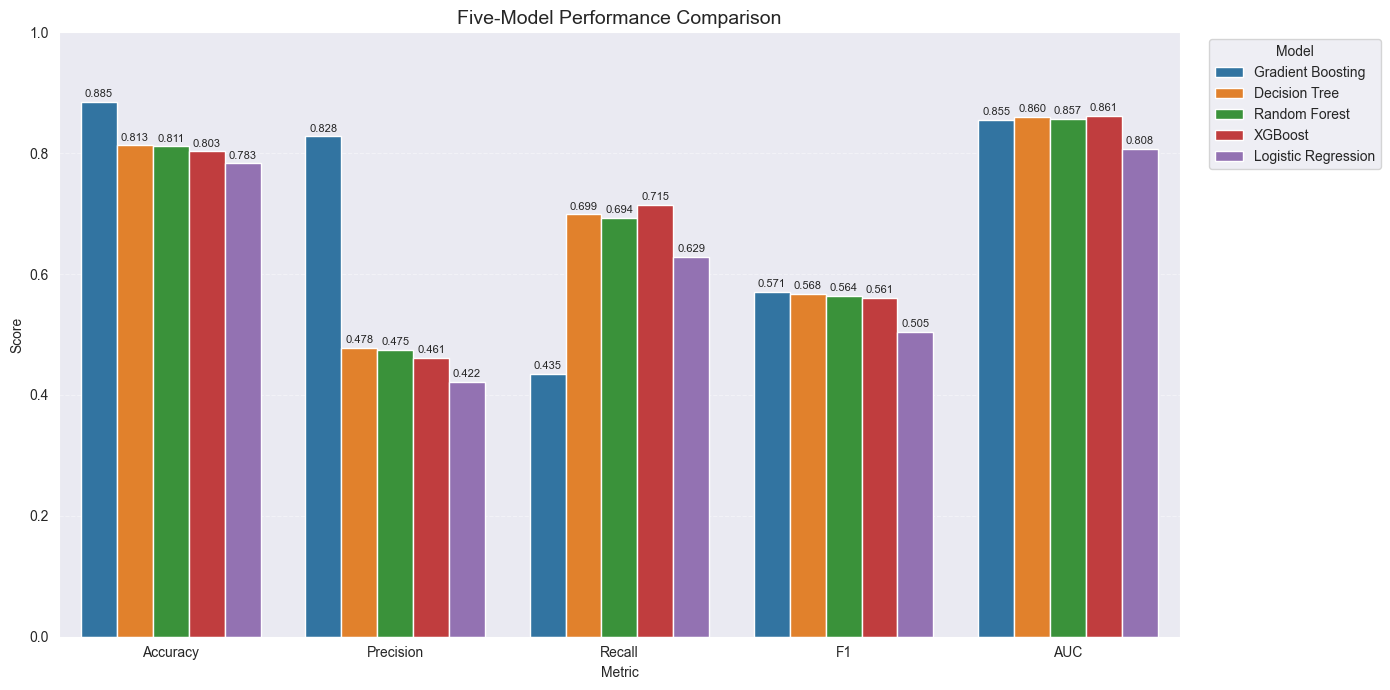

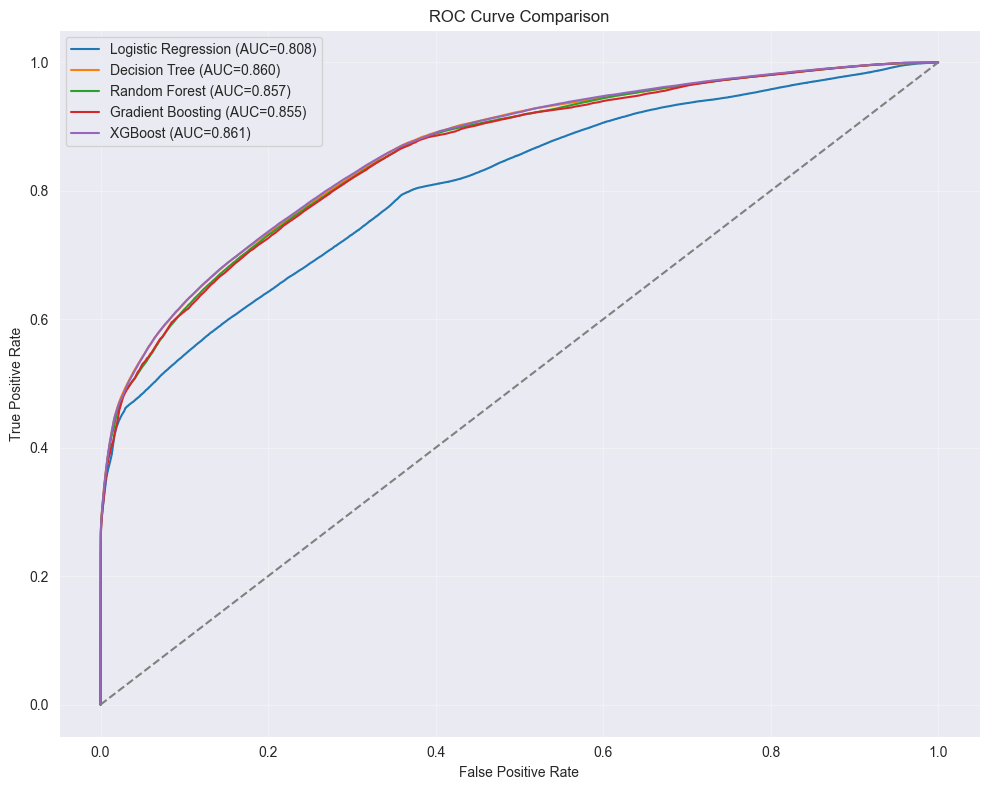

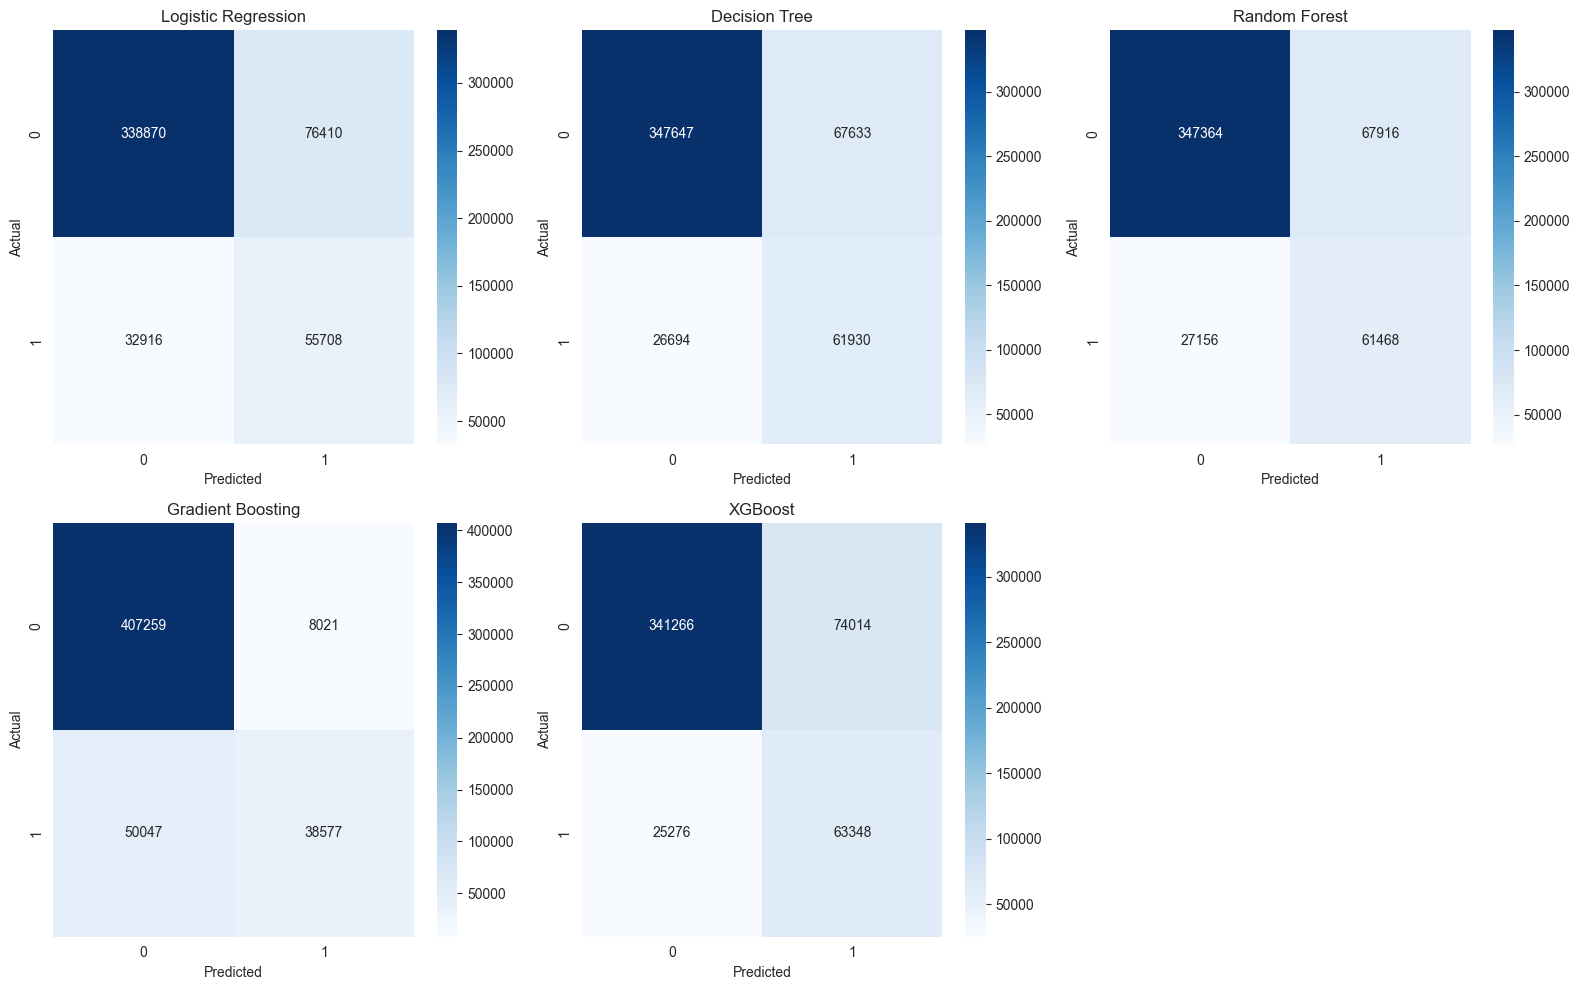

In [42]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)


from xgboost import XGBClassifier

pos_count = int((y_train == 1).sum())
neg_count = int((y_train == 0).sum())
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        solver="lbfgs"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

X_train_xgb = X_train.astype(int)
X_test_xgb = X_test.astype(int)


results = []
conf_matrices = {}
roc_curves = {}
reports = {}

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"{model_name}")
    print(f"{'='*80}")

    if model_name == "XGBoost":
        model.fit(X_train_xgb, y_train)
        y_pred = model.predict(X_test_xgb)
        y_prob = model.predict_proba(X_test_xgb)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

    conf_matrices[model_name] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves[model_name] = (fpr, tpr, auc)
    reports[model_name] = classification_report(y_test, y_pred, zero_division=0)

    print("Confusion Matrix:")
    print(conf_matrices[model_name])
    print("\nClassification Report:")
    print(reports[model_name])
    print(f"AUC: {auc:.4f}")

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison:")
print(results_df)

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.title("Five-Model Performance Comparison", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, auc_score) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models.keys()):
    cm = conf_matrices[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx])
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

if len(models) < len(axes):
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3.Cross-Validation

The selected model showed stable performance across folds, although the precision-recall trade-off was sensitive to class imbalance handling.

A 5-fold cross-validation was conducted for the Decision Tree model. The results showed relatively small variation across folds in accuracy, recall, F1-score, and AUC, suggesting that the model did not perform well merely due to a fortunate single train/test split. Its performance was stable across different data partitions.

A robustness experiment was also conducted by comparing the balanced Decision Tree with an unweighted Decision Tree. The AUC remained nearly unchanged, but the precision-recall trade-off shifted substantially: the unweighted model produced much higher precision but much lower recall. This indicates that the model is sensitive to class weighting, while its overall ranking ability remains stable.

In [43]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier

X_cv_sample, _, y_cv_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

dt_cv_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

cv_results = cross_validate(
    dt_cv_model,
    X_cv_sample,
    y_cv_sample,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

for metric in cv_results:
    print(metric, cv_results[metric])

print("Mean Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())
print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean F1:", cv_results['test_f1'].mean())
print("Mean AUC:", cv_results['test_roc_auc'].mean())

fit_time [0.04854226 0.04954338 0.04854226 0.05054331 0.04854226]
score_time [0.00750852 0.0080111  0.00901222 0.00701118 0.00750852]
test_accuracy [0.7964 0.8057 0.8043 0.7932 0.8061]
test_precision [0.44825019 0.46357878 0.45925926 0.44100802 0.46476116]
test_recall [0.68486917 0.66571916 0.63445139 0.65662308 0.67481524]
test_f1 [0.54185419 0.54655776 0.53282406 0.52763819 0.55042894]
test_roc_auc [0.82366446 0.82363122 0.8110918  0.81394633 0.83038919]
Mean Accuracy: 0.80114
Mean Precision: 0.45537148067690414
Mean Recall: 0.6632956076372383
Mean F1: 0.5398606269595367
Mean AUC: 0.8205446004037927


# 4.Hyperparameter Tuning

The training pipeline was complete, and the most promising model was further optimized through systematic tuning.

All models were trained on the training set and evaluated on the test set. Since the target variable was imbalanced, class_weight='balanced' was used to improve detection of the minority class (Arrest=1). After model comparison, Decision Tree was selected for further tuning using GridSearchCV. The search covered max_depth, min_samples_split, and min_samples_leaf. Although the tuned model did not significantly outperform the original tree on the final test set, the tuning process confirmed that the original Decision Tree was already a strong candidate.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_cv_sample, y_cv_sample)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1: 0.5575164845718055


In [45]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

def objective(trial, X, y):

    depth = trial.suggest_int('max_depth', 3, 50)
    split = trial.suggest_int('min_samples_split', 2, 100)
    leaf = trial.suggest_int('min_samples_leaf', 2, 100)
    
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        class_weight='balanced',
        random_state=42
    )
    f1 = cross_val_score(clf, X, y, cv=5, scoring='f1').mean()
    roc_auc = cross_val_score(clf, X, y, cv=5, scoring='roc_auc').mean()
    
    return f1, roc_auc

study = optuna.create_study(directions=['maximize', 'maximize'])

study.optimize(
    lambda t: objective(t, X_cv_sample, y_cv_sample), 
    n_trials=100
)

best_trials = study.best_trials

for trial in best_trials:
    print(f"params: {trial.params}：{trial.values}")

best_f1_trial = max(study.best_trials, key=lambda t: t.values[0])
print(f"Finali {best_f1_trial.params}")

[I 2026-04-20 18:58:20,281] A new study created in memory with name: no-name-b0dd3deb-8a73-49a0-a1f0-9b05430a20d3
[I 2026-04-20 18:58:20,814] Trial 0 finished with values: [0.5395061290538686, 0.8441576944272324] and parameters: {'max_depth': 47, 'min_samples_split': 47, 'min_samples_leaf': 88}.
[I 2026-04-20 18:58:21,264] Trial 1 finished with values: [0.5591586420792856, 0.848373122260425] and parameters: {'max_depth': 9, 'min_samples_split': 60, 'min_samples_leaf': 65}.
[I 2026-04-20 18:58:21,816] Trial 2 finished with values: [0.5372071475186619, 0.8394473720826342] and parameters: {'max_depth': 39, 'min_samples_split': 70, 'min_samples_leaf': 62}.
[I 2026-04-20 18:58:22,346] Trial 3 finished with values: [0.5387865754925547, 0.8435145211210877] and parameters: {'max_depth': 40, 'min_samples_split': 76, 'min_samples_leaf': 86}.
[I 2026-04-20 18:58:22,871] Trial 4 finished with values: [0.5384567636979294, 0.8442615023305873] and parameters: {'max_depth': 43, 'min_samples_split': 90

params: {'max_depth': 3, 'min_samples_split': 72, 'min_samples_leaf': 27}：[0.5867344782391941, 0.8238042329612687]
params: {'max_depth': 3, 'min_samples_split': 49, 'min_samples_leaf': 54}：[0.5867344782391941, 0.8238042329612687]
params: {'max_depth': 3, 'min_samples_split': 86, 'min_samples_leaf': 25}：[0.5867344782391941, 0.8238042329612687]
params: {'max_depth': 7, 'min_samples_split': 44, 'min_samples_leaf': 90}：[0.5614798807055956, 0.8520925977495939]
Finali {'max_depth': 3, 'min_samples_split': 72, 'min_samples_leaf': 27}


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

best_dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

best_dt_model.fit(X_train, y_train)

y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_best_dt))

Confusion Matrix:
[[353738  61542]
 [ 28241  60383]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89    415280
           1       0.50      0.68      0.57     88624

    accuracy                           0.82    503904
   macro avg       0.71      0.77      0.73    503904
weighted avg       0.85      0.82      0.83    503904


AUC-ROC:
0.8593543755666158


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

dt_random_search = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=17,
    min_samples_split=34,
    class_weight='balanced',
    random_state=42
)

dt_random_search.fit(X_train, y_train)

y_pred_dt_random = dt_random_search.predict(X_test)
y_prob_dt_random = dt_random_search.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_random))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_random))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_dt_random))

Confusion Matrix:
[[373241  42039]
 [ 35733  52891]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91    415280
           1       0.56      0.60      0.58     88624

    accuracy                           0.85    503904
   macro avg       0.73      0.75      0.74    503904
weighted avg       0.85      0.85      0.85    503904


AUC-ROC:
0.8426870381490044


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

best_dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=26,
    min_samples_split=54,
    class_weight='balanced',
    random_state=42
)

best_dt_model.fit(X_train, y_train)

y_pred_best_dt = best_dt_model.predict(X_test)
y_prob_best_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_best_dt))

Confusion Matrix:
[[363199  52081]
 [ 31636  56988]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90    415280
           1       0.52      0.64      0.58     88624

    accuracy                           0.83    503904
   macro avg       0.72      0.76      0.74    503904
weighted avg       0.85      0.83      0.84    503904


AUC-ROC:
0.8497259413993066


During the further optimization of the Decision Tree model, we evaluated three representative parameter settings: a deeper tree (max_depth = 8), a shallower tree (max_depth = 4), and an intermediate version (max_depth = 5). The results show that the max_depth = 8 model achieved the highest Recall and AUC, indicating that it was more effective at identifying incidents that truly resulted in arrest and had the strongest overall discriminative ability. However, its Precision was relatively lower, suggesting a higher number of false positives. In contrast, the max_depth = 4 model achieved the highest Accuracy and Precision, with a slightly improved F1-score, indicating that this model was more conservative and tended to predict arrest only when it had stronger confidence. As a result, it produced fewer false positives, but at the cost of a substantial reduction in Recall, meaning that more true arrest cases were missed. These findings further demonstrate that the complexity of a Decision Tree has a significant impact on the Precision–Recall trade-off. Therefore, the final model selection should be made by balancing these metrics according to the specific priorities of the task.

# 5.Feature Importance

Crime type is the most important predictor of arrest, followed by location, while time plays a secondary but still meaningful role.

Feature importance analysis based on the Decision Tree showed that the most influential variables were:

crime_against_Society

UNIFIED_LOCATION_CODE

crime_against_Person

offense_category_name_Other Offenses

hour

This indicates that crime type contributes the strongest signal to arrest prediction, especially the high-level crime_against categories. Location type is also highly informative, while temporal variables are less dominant overall. Among temporal variables, hour contributes the most useful predictive information.

                                            feature    importance
10                            crime_against_Society  5.781388e-01
0                             UNIFIED_LOCATION_CODE  1.803340e-01
8                              crime_against_Person  1.125497e-01
26             offense_category_name_Other Offenses  9.406416e-02
24     offense_category_name_Larceny/Theft Offenses  1.274088e-02
18     offense_category_name_Drug/Narcotic Offenses  7.784044e-03
3                                              hour  4.874142e-03
21          offense_category_name_Homicide Offenses  2.920461e-03
12           offense_category_name_Assault Offenses  2.106225e-03
19             offense_category_name_Fraud Offenses  2.020576e-03
31  offense_category_name_Trespass of Real Property  1.329118e-03
29                    offense_category_name_Robbery  1.137735e-03
1                                             month  6.437870e-08
7                         crime_against_Not a Crime  0.000000e+00
5         

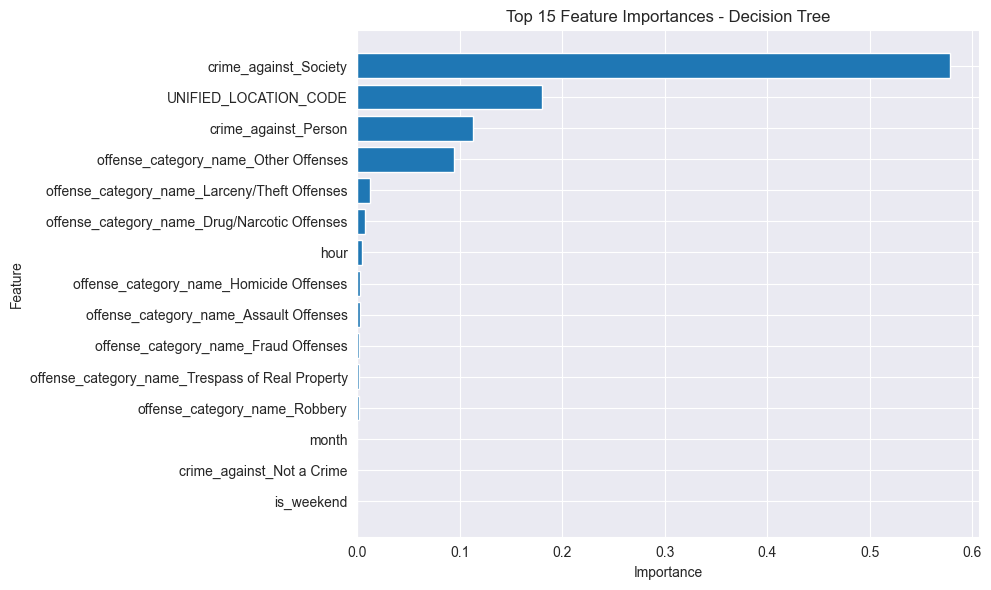

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_dt_model.feature_importances_
})


feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance_df.head(15))

top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

The Decision Tree model mainly relies on crime type, especially crime_against, and location to determine whether an incident is likely to result in an arrest. Among the temporal features, only hour shows a noticeable effect, while the influence of the other time-related variables is relatively much weaker.

# 6. Spatial & Temporal accuracy evaluation

## 6.1 Spatial accuracy evaluation

Model performance varies substantially across location types, indicating strong spatial heterogeneity in arrest predictability.

   UNIFIED_LOCATION_CODE   count  accuracy  precision    recall        f1
1                      2  173688  0.863969   0.675877  0.771431  0.720500
5                      6    2294  0.880994   0.609948  0.652661  0.630582
9                     10   91187  0.874774   0.660101  0.589041  0.622550
8                      9    8311  0.915654   0.588928  0.586854  0.587889
6                      7    2437  0.860074   0.454068  0.565359  0.503639
3                      4   35702  0.535852   0.345637  0.839493  0.489668
4                      5    4230  0.784870   0.414343  0.563686  0.477612
7                      8    4824  0.887852   0.352403  0.373786  0.362780
0                      1  172728  0.854627   0.346128  0.352901  0.349482
2                      3    8503  0.503234   0.225208  0.495034  0.309578


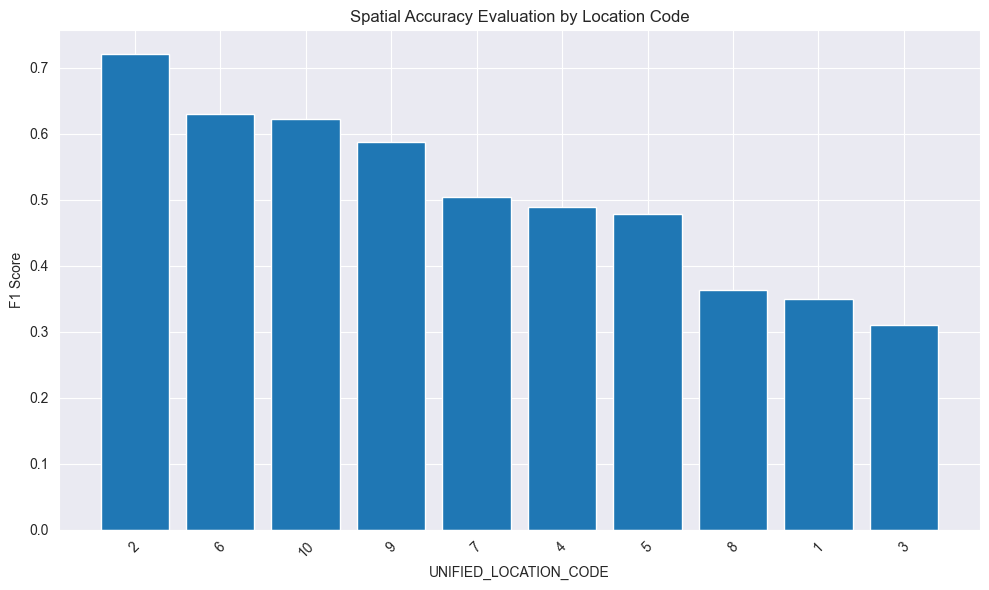

In [50]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

X_test_original = X.loc[X_test.index].copy()

spatial_eval_df = pd.DataFrame({
    'UNIFIED_LOCATION_CODE': X_test_original['UNIFIED_LOCATION_CODE'],
    'y_true': y_test,
    'y_pred': y_pred_best_dt
})

spatial_results = []

for loc_code, group in spatial_eval_df.groupby('UNIFIED_LOCATION_CODE'):
    if len(group) > 0:
        spatial_results.append({
            'UNIFIED_LOCATION_CODE': loc_code,
            'count': len(group),
            'accuracy': accuracy_score(group['y_true'], group['y_pred']),
            'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
            'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
            'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
        })

spatial_results_df = pd.DataFrame(spatial_results)
spatial_results_df = spatial_results_df.sort_values(by='f1', ascending=False)

print(spatial_results_df)


plt.figure(figsize=(10, 6))
plt.bar(spatial_results_df['UNIFIED_LOCATION_CODE'].astype(str), spatial_results_df['f1'])
plt.xlabel("UNIFIED_LOCATION_CODE")
plt.ylabel("F1 Score")
plt.title("Spatial Accuracy Evaluation by Location Code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6 = Government/Public

2 = Street/Outdoor

4 = Retail/Commercial

9 = Parking Lot

7 = Medical Facility

3 = Transportation Hub

10 = Unknown/Other

5 = Entertainment

8 = Workplace/Office

1 = Residence

## 6.2 Temporal accuracy evaluation

Arrest predictability follows clear time-of-day patterns, with weaker performance overnight and stronger performance during daytime and early evening.

    hour  count  accuracy  precision    recall        f1
0      0  30325  0.762572   0.339170  0.790958  0.474759
1      1  15759  0.650041   0.311480  0.807458  0.449546
2      2  13786  0.642681   0.275812  0.785120  0.408217
3      3  11464  0.654222   0.257273  0.760442  0.384472
4      4   9335  0.668452   0.235846  0.722504  0.355611
5      5   8017  0.864663   0.311728  0.240190  0.271323
6      6   9011  0.871823   0.522549  0.443797  0.479964
7      7  12081  0.868802   0.490760  0.460205  0.474992
8      8  17393  0.872247   0.513802  0.505254  0.509492
9      9  22533  0.880620   0.551601  0.520134  0.535406
10    10  22026  0.864478   0.631919  0.628953  0.630432
11    11  22916  0.857829   0.652034  0.681257  0.666325
12    12  30161  0.878054   0.605489  0.653297  0.628485
13    13  23604  0.857609   0.603532  0.660607  0.630781
14    14  25209  0.851323   0.566620  0.637560  0.600000
15    15  27441  0.850370   0.555012  0.607326  0.579992
16    16  26644  0.840865   0.5

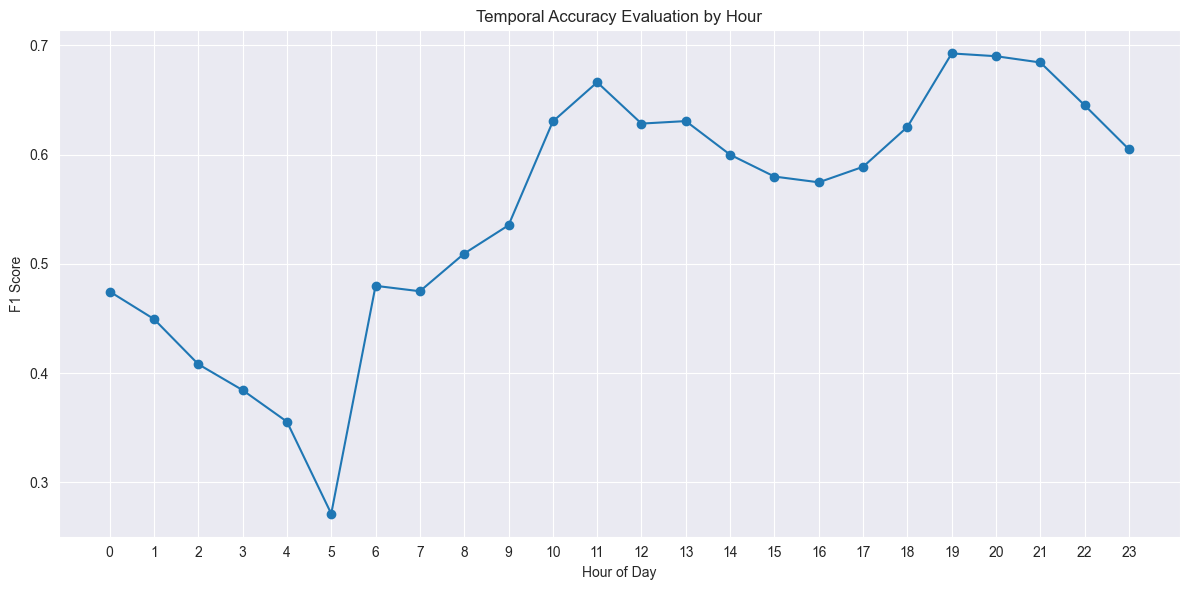

In [51]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

X_test_original = X.loc[X_test.index].copy()

temporal_eval_df = pd.DataFrame({
    'hour': X_test_original['hour'],
    'y_true': y_test,
    'y_pred': y_pred_best_dt
})

temporal_results = []

for hour, group in temporal_eval_df.groupby('hour'):
    if len(group) > 0:
        temporal_results.append({
            'hour': hour,
            'count': len(group),
            'accuracy': accuracy_score(group['y_true'], group['y_pred']),
            'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
            'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
            'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
        })

temporal_results_df = pd.DataFrame(temporal_results)
temporal_results_df = temporal_results_df.sort_values(by='hour')

print(temporal_results_df)

plt.figure(figsize=(12, 6))
plt.plot(temporal_results_df['hour'], temporal_results_df['f1'], marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("F1 Score")
plt.title("Temporal Accuracy Evaluation by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

1.The model performs worst in predicting arrest outcomes during the early morning hours, especially between 4:00 and 5:00, where the F1-score is the lowest.

2.After 9:00 a.m., the model performance improves noticeably, with a relatively stable high-performance period observed between 10:00 and 15:00.

3.The model performs well again during the evening hours from 18:00 to 21:00, with 19:00 showing the best performance of the entire day.

4.These results indicate that arrest patterns vary significantly across different time periods, and that hour provides meaningful predictive value for the model.

In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test_original = X.loc[X_test.index].copy()

weekend_eval_df = pd.DataFrame({
    'is_weekend': X_test_original['is_weekend'],
    'y_true': y_test,
    'y_pred': y_pred_best_dt
})

weekend_results = []

for weekend_flag, group in weekend_eval_df.groupby('is_weekend'):
    weekend_results.append({
        'is_weekend': weekend_flag,
        'count': len(group),
        'accuracy': accuracy_score(group['y_true'], group['y_pred']),
        'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
        'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
        'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0)
    })

weekend_results_df = pd.DataFrame(weekend_results)

weekend_results_df['day_type'] = weekend_results_df['is_weekend'].map({
    0: 'Weekday',
    1: 'Weekend'
})

print(weekend_results_df[['day_type', 'count', 'accuracy', 'precision', 'recall', 'f1']])

  day_type   count  accuracy  precision    recall        f1
0  Weekday  359494  0.840954   0.539171  0.643562  0.586759
1  Weekend  144410  0.816211   0.485333  0.641722  0.552677


In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dt_unbalanced = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_unbalanced.fit(X_train, y_train)

y_pred_unbalanced = dt_unbalanced.predict(X_test)
y_prob_unbalanced = dt_unbalanced.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_unbalanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_unbalanced))

print("\nAUC-ROC:")
print(roc_auc_score(y_test, y_prob_unbalanced))

Confusion Matrix:
[[407157   8123]
 [ 48044  40580]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94    415280
           1       0.83      0.46      0.59     88624

    accuracy                           0.89    503904
   macro avg       0.86      0.72      0.76    503904
weighted avg       0.88      0.89      0.87    503904


AUC-ROC:
0.8597239174438681


This experiment demonstrates that the Decision Tree model is highly sensitive to the class_weight setting. After removing balanced, the model becomes noticeably more conservative: Precision increases substantially, while Recall decreases sharply.

# 7.conclusion

## 7.1 Overall Model Comparison

In [54]:
import pandas as pd

final_model_comparison = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Logistic Regression'
    ],
    'Accuracy': [0.884764, 0.812808, 0.811329, 0.802959, 0.783042],
    'Precision_1': [0.827868, 0.477991, 0.475082, 0.461176, 0.421653],
    'Recall_1': [0.435288, 0.698795, 0.693582, 0.714795, 0.628588],
    'F1_1': [0.570573, 0.567678, 0.563906, 0.560636, 0.504734],
    'AUC': [0.855334, 0.860352, 0.857196, 0.861148, 0.807573]
})

print(final_model_comparison)

best_model_summary = {
    "Selected Model": "Decision Tree (class_weight='balanced')",
    "Reason": (
        "Although Gradient Boosting achieved the highest accuracy, precision, and slightly the highest F1-score, "
        "Decision Tree provided a stronger balance between recall and AUC while remaining highly interpretable. "
        "Compared with XGBoost, Decision Tree delivered similar overall performance with a simpler structure, "
        "making it more suitable for interpretation and subgroup analysis in this project."
    )
}

print(best_model_summary)

                 Model  Accuracy  Precision_1  Recall_1      F1_1       AUC
0    Gradient Boosting  0.884764     0.827868  0.435288  0.570573  0.855334
1        Decision Tree  0.812808     0.477991  0.698795  0.567678  0.860352
2        Random Forest  0.811329     0.475082  0.693582  0.563906  0.857196
3              XGBoost  0.802959     0.461176  0.714795  0.560636  0.861148
4  Logistic Regression  0.783042     0.421653  0.628588  0.504734  0.807573
{'Selected Model': "Decision Tree (class_weight='balanced')", 'Reason': 'Although Gradient Boosting achieved the highest accuracy, precision, and slightly the highest F1-score, Decision Tree provided a stronger balance between recall and AUC while remaining highly interpretable. Compared with XGBoost, Decision Tree delivered similar overall performance with a simpler structure, making it more suitable for interpretation and subgroup analysis in this project.'}


Logistic Regression served as a useful baseline, but its overall performance was clearly weaker than the tree-based models across all major metrics. Among the five models, Gradient Boosting achieved the highest Accuracy, Precision, and slightly the highest F1-score, which suggests strong overall classification performance and a relatively conservative prediction style. However, its Recall was much lower than that of the other tree-based models, meaning that it missed a larger proportion of true arrest cases.

XGBoost achieved the highest Recall and the highest AUC, indicating the strongest ability to detect positive arrest cases and the best overall ranking performance. Decision Tree and Random Forest performed similarly, with Decision Tree showing slightly better F1-score and AUC than Random Forest. Although Decision Tree was not the single best model on every metric, it maintained a strong balance between Recall, F1-score, and AUC, while also remaining far more interpretable than the more complex ensemble models.

Therefore, Decision Tree (`class_weight='balanced'`) was selected as the final model for this project. The reason was not that it dominated all alternatives numerically, but that it combined competitive predictive performance with clear interpretability, making it the most suitable model for subsequent feature-importance analysis and spatial–temporal subgroup evaluation.

## 7.2 Feature Importance and Model Interpretation

Crime type is the strongest predictor of arrest, followed by location, while time contributes additional but comparatively weaker predictive signal.

Feature-importance analysis based on the final Decision Tree model showed that the most influential variables were primarily related to broad crime categories and place. The top predictors included `crime_against_Society`, `UNIFIED_LOCATION_CODE`, `crime_against_Person`, and `offense_category_name_Other Offenses`, followed by `offense_category_name_Larceny/Theft Offenses`. This indicates that high-level crime-type information contributes the strongest signal to arrest prediction, while location type is also highly informative. Temporal variables are less dominant overall; among them, `hour` is the most useful time-related feature, although it is not among the very top predictors.

This interpretation is consistent with the subgroup evaluation results. Spatially, the model performs much better in some location categories than in others, showing strong spatial heterogeneity in arrest predictability. In particular, `Street/Outdoor` locations show the strongest and most stable predictive performance, while categories such as `Transportation Hub` and `Residence` are more difficult to classify accurately. Temporally, arrest predictability follows a clear hourly pattern: the weakest performance occurs in the early morning, especially around 5:00 a.m., while performance improves substantially after 9:00 a.m. and remains relatively strong through daytime and early evening. The best hourly performance appears around 19:00. In addition, weekday predictions are generally more stable than weekend predictions, while weekends tend to show lower precision and overall F1-score.

Overall, the Decision Tree mainly relies on crime type and location to distinguish likely arrest outcomes, while time functions as a secondary but still meaningful source of predictive information.

## 7.3 robustness

The model shows reasonably stable performance across different data splits, but it is also clearly sensitive to how class imbalance is handled.

First, a 5-fold cross-validation was conducted for the Decision Tree model on a stratified sample of the training data. The average cross-validation performance was approximately 0.801 in Accuracy, 0.455 in Precision, 0.663 in Recall, 0.540 in F1-score, and 0.821 in AUC. The variation across folds was relatively small, suggesting that the model’s performance was not driven only by a fortunate single train/test split. In other words, the model demonstrates a fair degree of stability across different partitions of the data.

Second, a robustness comparison was carried out between the balanced Decision Tree and an unweighted Decision Tree. The results showed that AUC remained almost unchanged, while the Precision–Recall trade-off shifted substantially. After removing `class_weight='balanced'`, the model became much more conservative: Precision increased sharply and Accuracy also improved, but Recall dropped considerably. This means that the unweighted model generated fewer false positives, but it also failed to identify many more true arrest cases.

Taken together, these findings suggest that the Decision Tree is relatively robust in terms of overall predictive structure, but highly sensitive to the class-weight setting. Therefore, the practical usefulness of the model depends on the objective of the task: if identifying as many true arrest cases as possible is more important, the balanced version is preferable; if avoiding false positives is more important, the unweighted version may appear more attractive.

## 7.4 Limitations

Although the model shows clear predictive value, it is constrained by the limited scope of the available data.

1. The model only uses location, time, and crime-type variables, without access to potentially important contextual factors such as police response time, patrol deployment, officer availability, witness information, case complexity, or investigation progress.

2. Some spatial subgroups contain relatively small numbers of observations, so subgroup-level performance estimates may be less stable than the overall results.

3. The analysis is predictive rather than causal. It identifies statistical associations with arrest outcomes, but it should not be interpreted as explaining the true causes of arrest decisions.

4. The model should not be treated as making deterministic judgments about individual incidents, especially in high-stakes settings.

For these reasons, the model is most useful for understanding broad data patterns and supporting exploratory analysis, rather than for direct automated decision-making.